In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt


datar = np.loadtxt("2mmR.dat", delimiter=",")  
datas = np.loadtxt("2mmS.dat", delimiter=",")  
tr, sr = datar[:,0], datar[:,1]
ts, ss = datas[:,0], datas[:,1]

startt, endt = 0.0, 4.6116e-11

dt = min(np.diff(ts).mean(), np.diff(tr).mean())
t  = np.arange(startt, endt+dt, dt)
sr = np.interp(t, tr, sr, left=0, right=0)
ss = np.interp(t, ts, ss, left=0, right=0)

# FFT 
Nfft = 16384
FFTr = np.fft.fft(sr,  Nfft)
FFTs = np.fft.fft(ss,  Nfft)
freq = np.fft.fftfreq(Nfft, dt)
mask = (freq > 0) & (freq < 3e12)
freq = freq[mask]

tf_exp = FFTs[mask] / FFTr[mask]



L = 2e-3       
c = 2.9979e8   
D_vals = 2 * np.pi * freq * L / c



def complex_cos(z):
    return 0.5*(torch.exp(1j*z) + torch.exp(-1j*z))

def complex_sin(z):
    return 0.5j*(torch.exp(-1j*z) - torch.exp(1j*z))

def rts(n0, nj, D):
    phi = nj * D
    cphi = complex_cos(phi)
    sphi = complex_sin(phi)
    denom = cphi + 0.5j*(nj/n0 + n0/nj)*sphi
    denom = denom + 1e-8*(torch.abs(denom)<1e-8)
    r = 0.5j*sphi*(n0/nj - nj/n0)/denom
    t = 1.0/denom
    return r, t*torch.exp(1j*n0*D)

def RTm(n0, nj, D):
    r, t_exp = rts(n0, nj, D)
    
    return t_exp



freq_t = torch.tensor(freq, dtype=torch.float32)
D_t = torch.tensor(D_vals, dtype=torch.float32)
Hexp = torch.tensor(tf_exp, dtype=torch.complex64)

# storage
n_real_list, n_imag_list = [], []
n_prev = torch.tensor(2.0)
k_prev = torch.tensor(0.005)

lr, epochs = 1e-3, 300
for i in range(len(freq)):
    nr = torch.nn.Parameter(n_prev.clone())
    ki = torch.nn.Parameter(k_prev.clone())
    opt = torch.optim.Adam([nr, ki], lr=lr)
    D = D_t[i]
    Hmeas = Hexp[i]

    for e in range(epochs):
        opt.zero_grad()
        n_complex = nr + 1j*ki
        Hth = RTm(1.0, n_complex, D)
        loss = (Hth.real-Hmeas.real)**2 + (Hth.imag-Hmeas.imag)**2
        loss = loss.mean()
        if loss.item()<1e-7:
            break
        loss.backward()
        opt.step()

    n_prev, k_prev = nr.detach(), ki.detach()
    n_real_list.append(n_prev.item())
    n_imag_list.append(k_prev.item())
    if i%50==0 or i==len(freq)-1:
        print(f"[{i:3d}] {freq[i]*1e-12:.2f} THz: n={n_prev:.4f}, k={k_prev:.4f}, loss={loss:.2e}")

# convert to numpy and plot
freq_THz = freq*1e-12
n_real = np.array(n_real_list)
k_imag = np.array(n_imag_list)



[  0] 0.00 THz: n=1.7150, k=-0.2793, loss=3.69e+02
[ 50] 0.16 THz: n=1.9777, k=0.0033, loss=5.11e-08
[100] 0.32 THz: n=1.9777, k=0.0013, loss=2.28e-08
[150] 0.48 THz: n=1.9800, k=0.0026, loss=4.40e-08
[200] 0.63 THz: n=1.9835, k=-0.0005, loss=9.07e-08
[250] 0.79 THz: n=1.9836, k=-0.0039, loss=6.44e-08
[300] 0.95 THz: n=1.9825, k=-0.0063, loss=9.65e-08
[350] 1.11 THz: n=1.9809, k=-0.0075, loss=6.88e-08
[400] 1.27 THz: n=1.9806, k=-0.0066, loss=7.06e-08
[450] 1.42 THz: n=1.9819, k=-0.0069, loss=1.08e-08
[500] 1.58 THz: n=1.9827, k=-0.0086, loss=6.37e-08
[550] 1.74 THz: n=1.9823, k=-0.0098, loss=7.75e-08
[600] 1.90 THz: n=1.9819, k=-0.0100, loss=7.46e-08
[650] 2.06 THz: n=1.9828, k=-0.0098, loss=5.02e-08
[700] 2.21 THz: n=1.9842, k=-0.0101, loss=8.18e-08
[750] 2.37 THz: n=1.9851, k=-0.0113, loss=8.57e-08
[800] 2.53 THz: n=1.9862, k=-0.0117, loss=4.35e-08
[850] 2.69 THz: n=1.9868, k=-0.0116, loss=5.29e-08
[900] 2.84 THz: n=1.9889, k=-0.0133, loss=8.84e-08
[949] 3.00 THz: n=1.9895, k=-0.012

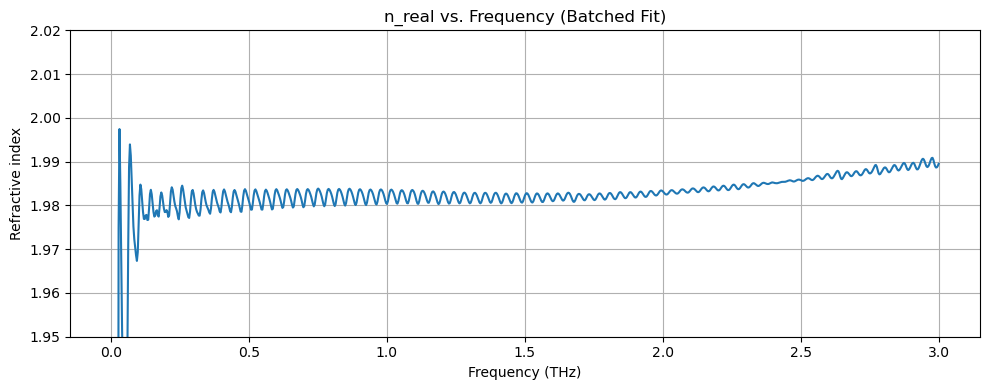

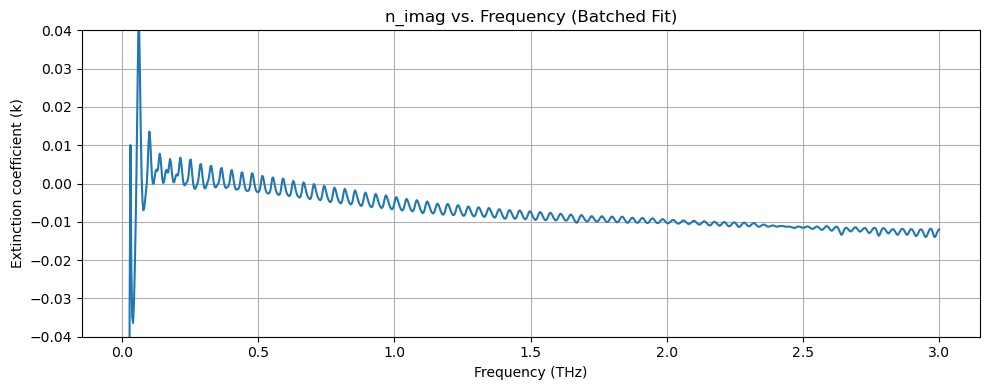

In [18]:

plt.figure(figsize=(10, 4))
plt.plot(freq_THz, n_real, color="tab:blue")
plt.ylim(1.95, 2.02)
plt.xlabel("Frequency (THz)")
plt.ylabel("Refractive index")
plt.title("n_real vs. Frequency (Batched Fit)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(freq_THz,k_imag, color="tab:blue")
plt.ylim(-0.04, 0.04)
plt.xlabel("Frequency (THz)")
plt.ylabel("Extinction coefficient (k)")
plt.title("n_imag vs. Frequency (Batched Fit)")
plt.grid(True)
plt.tight_layout()
plt.show()